# Stage 2 — DRS spectral shapes of difficult subjects
Generate two thesis-ready figures: one for tHb and one for StO₂. Each figure contains difficult over- and under-estimation panels defined only from the corresponding DRS-only LOSO baseline.

In [1]:
from pathlib import Path
import os, sys
import pandas as pd
ROOT = Path.cwd()
if not (ROOT / 'pyproject.toml').is_file():  # VS Code may start in notebooks/
    ROOT = ROOT.parent
if not (ROOT / 'pyproject.toml').is_file():
    raise RuntimeError('Open this notebook from final_refactored or its notebooks folder.')
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'src'))
from subject_nirs.stage2.subject_failure import (
    load_baseline_performance, load_or_compute_signatures,
    make_subject_failure_figure,
)
BASELINE_DIRS = {
    'hc': Path('artifacts/stage2/baseline/hc'),
    'sto2': Path('artifacts/stage2/baseline/sto2'),
}
VALIDATION_CACHE = Path('cache/stage2/preprocessed_cache_grid_50k')
SIGNATURE_CACHE = Path('cache/stage2/subject_failure/subject_mean_signatures.npz')
FIGURE_DIR = Path('results/figures/stage2')
TABLE_DIR = Path('results/tables/stage2/subject_failure')

## 1. Build intensity-balanced subject signatures
For every subject, the 30-channel DRS vectors are averaged within each HC × StO₂ target cell and then equally across cells. The compact signature cache is rebuildable and excluded from Git.

In [2]:
subject_ids, signatures = load_or_compute_signatures(
    SIGNATURE_CACHE,
    VALIDATION_CACHE / 'val_x_preprocessed.npy',
    VALIDATION_CACHE / 'val_y_all_targets.npy',
    VALIDATION_CACHE / 'val_subj_0based.npy',
    recompute=False,
)
subject_ids.shape, signatures.shape

((154,), (154, 30))

## 2. Generate the tHb and StO₂ thesis figures
For each target separately, the accurate reference is the lowest DRS-only RMSE quartile (Q1). Difficult subjects are the highest quartile (Q4), split by the sign of their DRS-only bias. The 30-channel signatures are relative optical density; channel contrasts subtract each subject's across-channel mean and use the target-specific Q1 group MAD as a robust scale.

,target,target_display,figure,common_n,accurate_n,difficult_n,overestimation_n,underestimation_n,zero_bias_difficult_n,rmse_q25,rmse_q75
0,hc,tHb,results/figures/stage2/subject_failure_hc.png,154,39,39,17,22,0,10.521772,17.889792
1,sto2,StO₂,results/figures/stage2/subject_failure_sto2.png,154,39,39,22,17,0,0.035095,0.069571


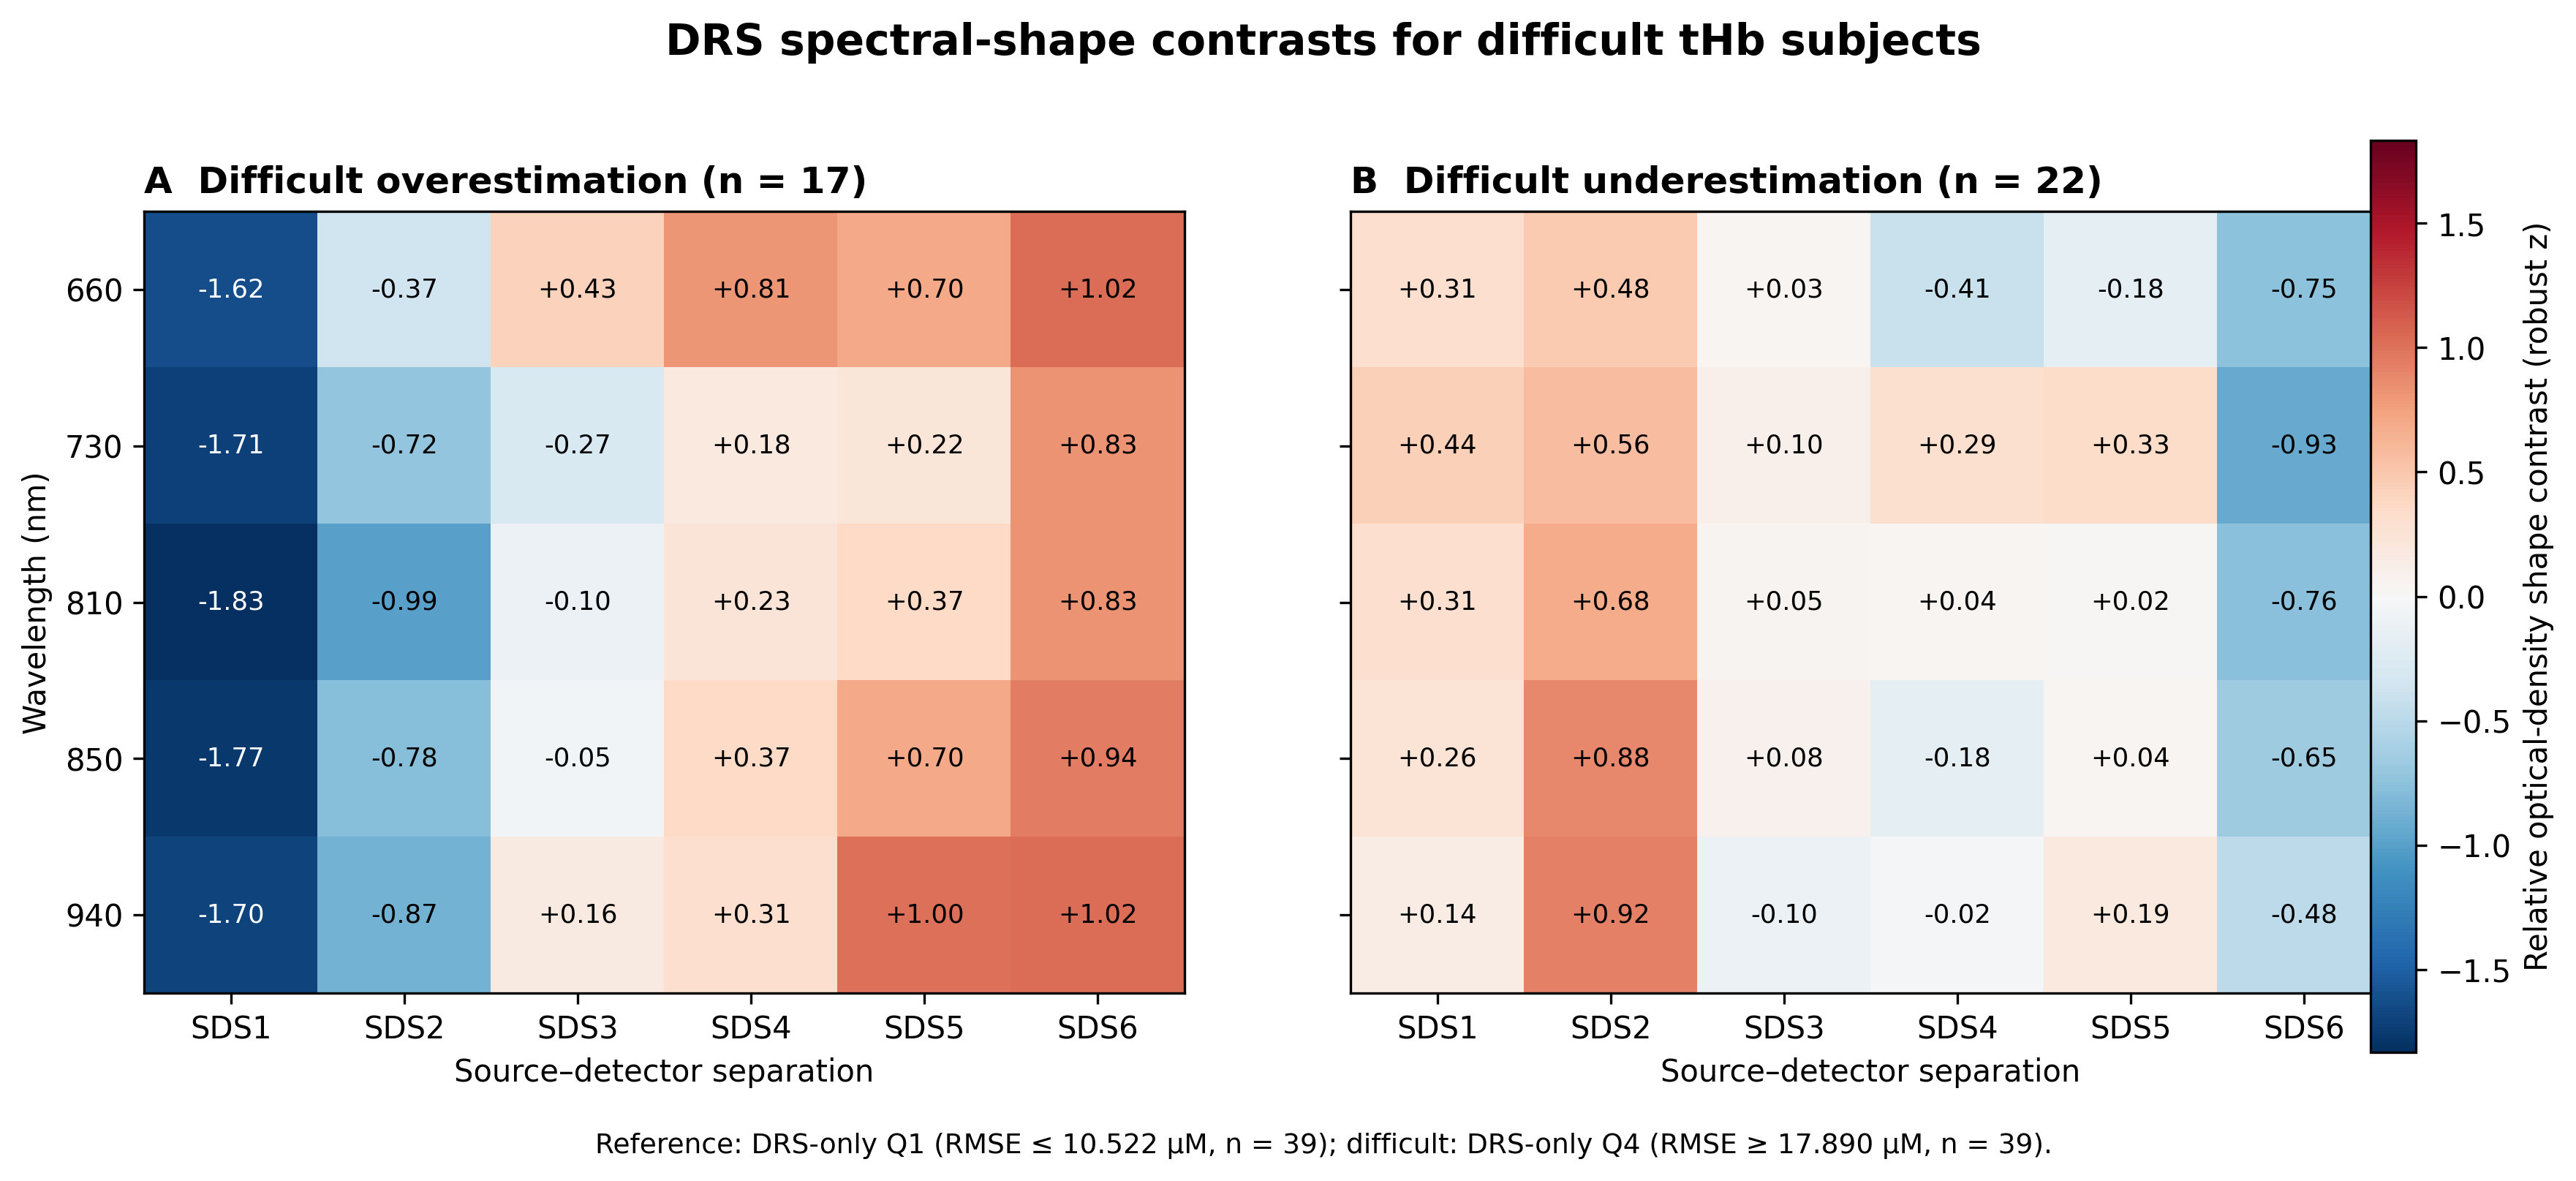

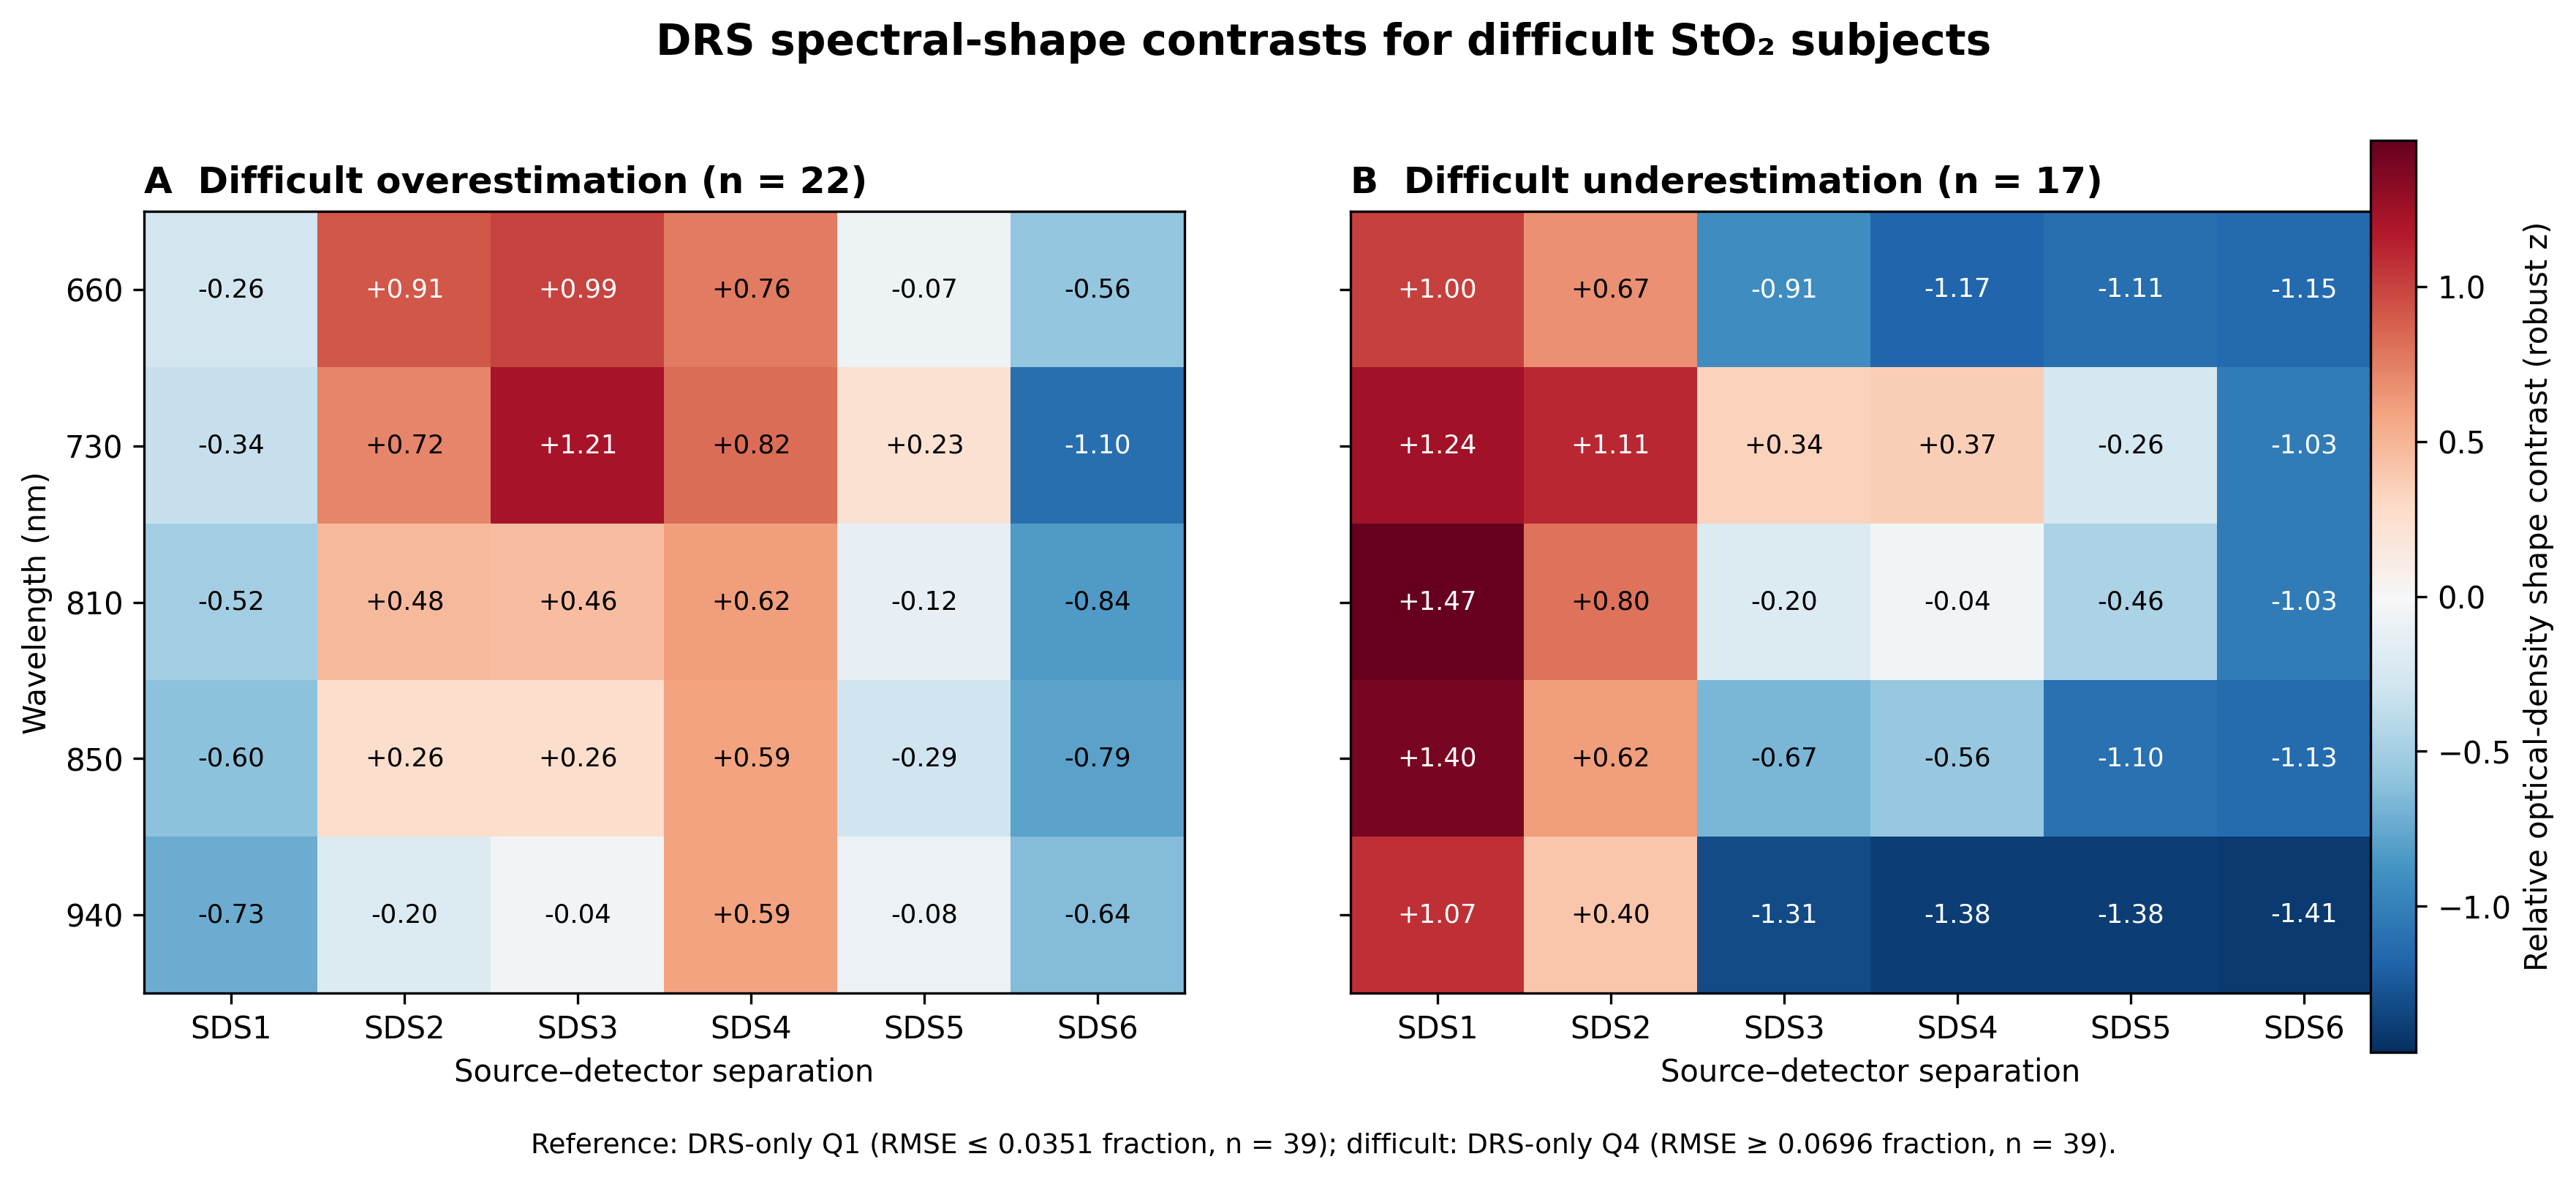

In [3]:
from IPython.display import Image, display

summaries = []
for target_mode, baseline_dir in BASELINE_DIRS.items():
    baseline_results = baseline_dir / 'loso_results.csv'
    if not baseline_results.is_file():
        raise FileNotFoundError(
            f'Run the {target_mode} DRS-only LOSO experiment first. Missing: {baseline_results}'
        )
    performance = load_baseline_performance(baseline_dir, target_mode)
    summaries.append(
        make_subject_failure_figure(
            performance, subject_ids, signatures, FIGURE_DIR, target_mode
        )
    )

TABLE_DIR.mkdir(parents=True, exist_ok=True)
summary_table = pd.DataFrame(summaries)
summary_table.to_csv(TABLE_DIR / 'subject_failure_summary.csv', index=False)
display(summary_table)
for summary in summaries:
    display(Image(filename=summary['figure'], width=1300))
